# 10 · The real ML workflow, and how models cheat

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/10_ml_workflow_and_leakage.ipynb)

Real projects are mostly about building a clean, repeatable process: preprocessing that treats each column
correctly, honest cross-validation, tuning, rare outcomes, time-ordered data, and above all avoiding
**leakage**, where information the model would not really have at prediction time sneaks into training.
Leakage is the most common reason a finance model looks brilliant in testing and fails in production.

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = next((p for p in ["../data/", "../../data/"] if Path(p).exists()), "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/")
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
import sys
if Path("../checks.py").exists():
    sys.path.insert(0, "..")  # solution notebooks live one folder down
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


## 1. One pipeline for mixed column types
Numbers get scaled, text categories get one-hot encoded, and both steps live **inside** the pipeline so they are re-fitted on each training fold only.

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, TimeSeriesSplit, KFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

cr = pd.read_csv(DATA + "credit_default.csv")
X, y = cr.drop(columns="default"), cr["default"]
num = ["income_k", "debt_to_income", "fico", "loan_to_value", "years_employed", "home_owner"]
prep = ColumnTransformer([("num", StandardScaler(), num),
                          ("cat", OneHotEncoder(handle_unknown="ignore"), ["purpose"])])
pipe = Pipeline([("prep", prep), ("model", LogisticRegression(max_iter=1000))])
cv = StratifiedKFold(5, shuffle=True, random_state=0)
print("5-fold AUC per fold:", cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc").round(3))

5-fold AUC per fold: [0.834 0.864 0.864 0.82  0.782]


### Exercise 1

Store the **mean** 5-fold cross-validated AUC of `pipe` (same `cv`) in `cv_auc`.

<details><summary>Hint</summary>

`cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc').mean()`

</details>

In [3]:
# Your code here

In [4]:
check("10.1");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 10.1: not answered yet. Store your answer in `cv_auc`.


## 2. Tuning hyperparameters with cross-validation
`GridSearchCV` tries every combination, scores each with cross-validation, and refits the best on all the training data. Parameter names are `step__parameter`.

In [5]:
rf = Pipeline([("prep", prep), ("model", RandomForestClassifier(random_state=0, n_jobs=-1))])
grid = {"model__n_estimators": [200], "model__max_depth": [3, 6, None], "model__min_samples_leaf": [1, 10, 30]}
gs = GridSearchCV(rf, grid, cv=cv, scoring="roc_auc").fit(X, y)
res = pd.DataFrame(gs.cv_results_)[["param_model__max_depth", "param_model__min_samples_leaf", "mean_test_score"]]
print(res.sort_values("mean_test_score", ascending=False).round(3).to_string(index=False))
print("best:", gs.best_params_)

param_model__max_depth  param_model__min_samples_leaf  mean_test_score
                     6                              1            0.785
                     3                              1            0.785
                     6                             10            0.783
                     3                             10            0.783
                  None                             10            0.780
                  None                             30            0.777
                     3                             30            0.776
                     6                             30            0.776
                  None                              1            0.766
best: {'model__max_depth': 6, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


**Important:** the best CV score is now slightly optimistic, because you picked it out of many tries. Keep a final
**test set** that is never used for tuning, and look at it once at the end (or use nested cross-validation).

### Exercise 2

Tune the logistic pipeline’s regularisation strength over `C` in `[0.01, 0.1, 1, 10]` with `GridSearchCV(pipe, {'model__C': [...]}, cv=cv, scoring='roc_auc')`. Store the best C in `best_C`.

In [6]:
# Your code here

In [7]:
check("10.2");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 10.2: not answered yet. Store your answer in `best_C`.


## 3. Rare outcomes (imbalanced classes)
Only about 25% of loans default here; in fraud it can be 0.1%. Accuracy becomes meaningless, so use precision–recall, average precision, and a deliberately chosen threshold.

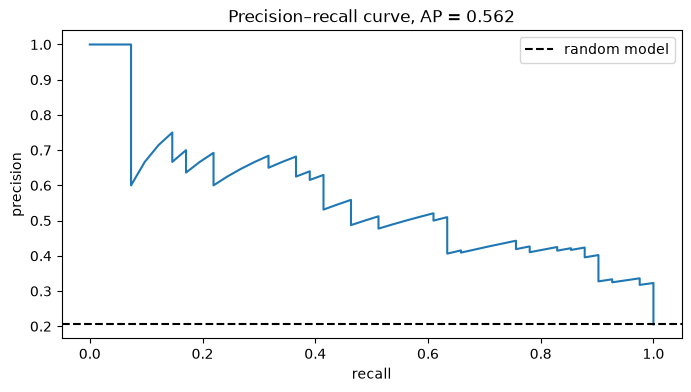

Default rate in test set: 0.205 → an AP near this means no skill


In [8]:
Xn = pd.get_dummies(X, columns=["purpose"], drop_first=True, dtype=float)
X_train, X_test, y_train, y_test = train_test_split(Xn, y, test_size=0.25, random_state=0, stratify=y)
plain = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
p = plain.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, p)
plt.plot(rec, prec); plt.axhline(y_test.mean(), color="k", ls="--", label="random model")
plt.xlabel("recall"); plt.ylabel("precision"); plt.title(f"Precision–recall curve, AP = {average_precision_score(y_test, p):.3f}"); plt.legend(); plt.show()
print("Default rate in test set:", round(y_test.mean(), 3), "→ an AP near this means no skill")

### Exercise 3

Fit the same model with `LogisticRegression(class_weight='balanced', max_iter=1000)` (still with StandardScaler). Store its test average precision in `ap_balanced`. Does re-weighting change the ranking quality (AP), or mainly where the 0.5 threshold falls?

In [9]:
# Your code here

In [10]:
check("10.3");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 10.3: not answered yet. Store your answer in `ap_balanced`.


## 4. Find the leak
Each setup below produces an impressive score. Each one cheats in a different way. Your job: run them, then match each to the kind of leak.

| Code | Kind of leak |
|---|---|
| **A** | A preprocessing step (scaling, feature selection) was fitted on all the data before splitting |
| **B** | A feature that is only known **after** the outcome (target leakage) |
| **C** | A feature computed with **future** information (look-ahead bias) |
| **D** | A **random** split of time-ordered data with overlapping targets, so test rows have near-copies in training |

### Leak 1: 2,000 features of pure noise

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif
rng = np.random.default_rng(42)
Xnoise = rng.normal(size=(200, 2000)); ynoise = rng.integers(0, 2, 200)        # no signal at all
top = SelectKBest(f_classif, k=20).fit(Xnoise, ynoise)                           # pick the 20 'best' features
leak1 = cross_val_score(LogisticRegression(max_iter=1000), top.transform(Xnoise), ynoise, cv=cv).mean()
print(f"Leak 1 accuracy on random coin flips: {leak1:.2f}")

Leak 1 accuracy on random coin flips: 0.80


### Leak 2: a near-perfect credit model

In [12]:
cr2 = cr.copy()
rng = np.random.default_rng(1)
cr2["sent_to_collections"] = ((cr2["default"] == 1) & (rng.random(len(cr2)) < 0.9)).astype(int)   # a field from the bank's system
X2 = pd.get_dummies(cr2.drop(columns="default"), columns=["purpose"], drop_first=True, dtype=float)
leak2 = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), X2, cr2["default"], cv=cv, scoring="roc_auc").mean()
print(f"Leak 2 AUC: {leak2:.3f}  (honest model: about {cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc').mean():.3f})")

Leak 2 AUC: 0.980  (honest model: about 0.833)


### Leak 3: predicting next month’s market direction

In [13]:
fr = pd.read_csv(DATA + "factor_returns.csv")
up_next = (fr["mkt_excess"].shift(-1) > 0).astype(int)
trend = fr["mkt_excess"].rolling(3, center=True).mean()                 # a smoothed 'trend' feature
d3 = pd.DataFrame({"trend": trend, "y": up_next}).dropna()
leak3 = cross_val_score(LogisticRegression(), d3[["trend"]], d3["y"], cv=TimeSeriesSplit(5)).mean()
print(f"Leak 3 accuracy: {leak3:.2f}  (always guessing 'up' gives {d3['y'].mean():.2f})")

Leak 3 accuracy: 0.73  (always guessing 'up' gives 0.54)


### Leak 4: forecasting 12-month index returns

In [14]:
px = pd.read_csv(DATA + "capstone_prices.csv", index_col=0, parse_dates=True)["INDEX"]
fwd12 = px.shift(-12) / px - 1                                           # 12-month forward return (overlapping)
d4 = pd.DataFrame({"t": np.arange(len(px)), "y": fwd12}).dropna()
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators=200, random_state=0)
leak4 = cross_val_score(rfr, d4[["t"]], d4["y"], cv=KFold(5, shuffle=True, random_state=0), scoring="r2").mean()
honest4 = cross_val_score(rfr, d4[["t"]], d4["y"], cv=TimeSeriesSplit(5), scoring="r2").mean()
print(f"Leak 4 R² with a random split: {leak4:.2f} | with a time-ordered split: {honest4:.2f}")

Leak 4 R² with a random split: 0.92 | with a time-ordered split: -1.98


### Exercise 4

Match each leak to A, B, C or D. Store your answers as `leak_answers = {'leak1': '?', 'leak2': '?', 'leak3': '?', 'leak4': '?'}`.

<details><summary>Hint</summary>

Leak 1: when was the feature selection done? Leak 2: when does a loan get sent to collections? Leak 3: what does `center=True` average over? Leak 4: neighbouring months share 11 of 12 months of returns.

</details>

In [15]:
# Your code here

In [16]:
check("10.4");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 10.4: not answered yet. Store your answer in `leak_answers`.


### Exercise 5

Fix leak 1: put `SelectKBest(f_classif, k=20)` **inside** a pipeline with the logistic regression and cross-validate the whole pipeline with the same `cv`. Store the mean accuracy in `cv_noise_fixed`. It should drop to about a coin flip.

In [17]:
# Your code here

In [18]:
check("10.5");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 10.5: not answered yet. Store your answer in `cv_noise_fixed`.


## 5. A leakage checklist for every project
1. **Split first.** Every step that learns from data (scaling, imputation, feature selection, encoding, PCA) goes inside the pipeline.
2. **Timestamp every feature.** Would you really know this value at the moment of prediction? Watch for fields updated after the event.
3. **Never shuffle time.** Use `TimeSeriesSplit` or a walk-forward split; add a gap when targets overlap (e.g. 12-month returns).
4. **Touch the test set once.** Tune on cross-validation, report the test score at the end.
5. **Be suspicious of great results.** In finance, a model that looks too good is usually leaking.

---
## Solutions

In [19]:
cv_auc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc").mean(); print("1) CV AUC", round(cv_auc, 4))
best_C = GridSearchCV(pipe, {"model__C": [0.01, 0.1, 1, 10]}, cv=cv, scoring="roc_auc").fit(X, y).best_params_["model__C"]; print("2) best C", best_C)
bal = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=1000)).fit(X_train, y_train)
ap_balanced = average_precision_score(y_test, bal.predict_proba(X_test)[:, 1])
print(f"3) AP balanced {ap_balanced:.3f} vs plain {average_precision_score(y_test, p):.3f}: ranking barely changes; the threshold moves")
leak_answers = {"leak1": "A", "leak2": "B", "leak3": "C", "leak4": "D"}
cv_noise_fixed = cross_val_score(make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=1000)), Xnoise, ynoise, cv=cv).mean()
print("5) honest accuracy on noise:", round(cv_noise_fixed, 3))
check_all("10")

1) CV AUC 0.833


2) best C 0.1
3) AP balanced 0.568 vs plain 0.562: ranking barely changes; the threshold moves
5) honest accuracy on noise: 0.57
✅ Exercise 10.1: correct.


✅ Exercise 10.2: correct.
✅ Exercise 10.4: correct.
✅ Exercise 10.5: correct.
✅ Exercise 10.3: correct.

5 of 5 exercises correct.
